Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 163,348 rows, 61 cols, default rate = 1.05%
Categorical column indices for SMOTE-NC: [4, 5, 6, 7, 8, 9, 10, 11, 12] (['PropType_Flat', 'PropType_Bungalow', 'PropType_Terraced', 'Purpose_Remortgage', 'Purpose_DebtConsolidation', 'Purpose_Renovation', 'Purpose_RemortgageEquityRelease', 'Purpose_Other', 'IncVerif_Other'])
Train: 130,678 rows, 1,377 events (1.05%)
Test: 32,670 rows, 344 events (1.05%) - held out untouched, never resampled

Best SMOTE-NC LR: C=0.001, CV PR-AUC=0.0181
Best SMOTE-NC RF: {'clf__max_depth': 10, 'clf__min_samples_leaf': 20, 'clf__n_estimators': 200}, CV PR-AUC=0.0171
Logistic Regression (SMOTE-NC): ROC-AUC=0.6634, PR-AUC=0.0182
Random Forest (SMOTE-NC): ROC-AUC=0.6534, PR-AUC=0.0173

Class-weighting vs SMOTE-NC comparison:
         LR (class-weighted) LR (SMOTE-NC)  RF (class-weighted) RF (SMOTE-NC)
ROC-AUC               0.7179

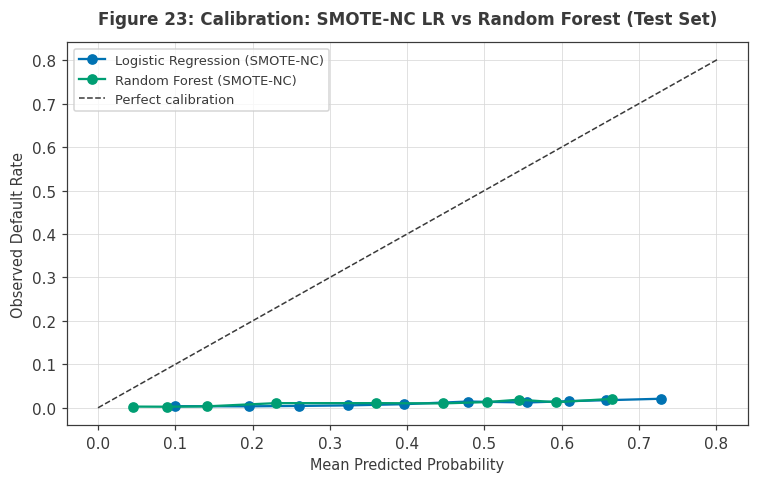


Saved comparison table to /content/drive/MyDrive/Dissertation/data/smote_vs_weighted_comparison.csv


In [1]:
# SMOTE-NC comparison script - tests whether synthetic oversampling
# improves LR/RF predictive performance over the class-weighting approach
# already used in the ML-comparison script. Separate/exploratory script;
# does not touch RQ1 or the inferential baseline model.
#
# SMOTE-NC (not vanilla SMOTE) is used because most predictors here are
# dummy-encoded categoricals; vanilla SMOTE's linear interpolation would
# produce nonsensical fractional dummy values (e.g. PropType_Flat=0.5).
# SMOTE-NC (Chawla et al., 2002 extension) handles categorical columns
# via majority-vote among neighbors instead of interpolation.
#
# Literature context: van den Goorbergh et al. (2022, J Clin Epidemiol)
# found SMOTE/class-balancing techniques did not improve AUC over
# class-weighting on comparable rare-event prediction tasks, and worsened
# calibration - this script tests that finding empirically on this data
# rather than assuming it holds.

# pip install imbalanced-learn - not preinstalled in Colab by default
!pip install -q imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline  # NOT sklearn's Pipeline -
                                                          # resamples inside each CV fold

from google.colab import drive
drive.mount("/content/drive")
DATA_FOLDER = "/content/drive/MyDrive/Dissertation/data"
RANDOM_STATE = 42

PALETTE = {
    "primary": "#0072B2", "highlight": "#D55E00", "secondary": "#009E73",
    "tertiary": "#E69F00", "neutral": "#3A3A3A",
}
plt.rcParams.update({
    "axes.edgecolor": PALETTE["neutral"], "axes.labelcolor": PALETTE["neutral"],
    "xtick.color": PALETTE["neutral"], "ytick.color": PALETTE["neutral"],
    "text.color": PALETTE["neutral"], "axes.grid": True,
    "grid.color": "#D9D9D9", "grid.linewidth": 0.5, "figure.dpi": 110,
})
FIGURE_COUNTER = {"n": 22}  # continues from the ML-comparison script's Figure 22

def styled_figure(title, xlabel, ylabel):
    FIGURE_COUNTER["n"] += 1
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_title(f"Figure {FIGURE_COUNTER['n']}: {title}",
                 fontsize=11, fontweight="bold", color=PALETTE["neutral"], pad=12)
    ax.set_xlabel(xlabel, fontsize=9.5)
    ax.set_ylabel(ylabel, fontsize=9.5)
    return fig, ax

# Step 1: Load data, same predictor set/split as the ML-comparison script
df = pd.read_csv(f"{DATA_FOLDER}/cleaned_dissertation_data.csv", low_memory=False)
print(f"Loaded: {len(df):,} rows, {df.shape[1]} cols, "
      f"default rate = {df['default'].mean():.2%}")

predictors = [
    "Original_LTV", "Interest_Rate", "Loan_Term", "Income_log",
    "PropType_Flat", "PropType_Bungalow", "PropType_Terraced",
    "Purpose_Remortgage", "Purpose_DebtConsolidation", "Purpose_Renovation",
    "Purpose_RemortgageEquityRelease", "Purpose_Other", "IncVerif_Other",
]
X = df[predictors].astype(float)
y = df["default"].astype(int)

# indices 0-3 are continuous (Original_LTV, Interest_Rate, Loan_Term,
# Income_log); everything from index 4 onward is a 0/1 dummy - tell
# SMOTENC which columns to treat as categorical
categorical_idx = list(range(4, len(predictors)))
print(f"Categorical column indices for SMOTE-NC: {categorical_idx} "
      f"({[predictors[i] for i in categorical_idx]})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows, {y_train.sum():,} events "
      f"({y_train.mean():.2%})")
print(f"Test: {len(X_test):,} rows, {y_test.sum():,} events "
      f"({y_test.mean():.2%}) - held out untouched, never resampled")

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Step 2: Tune LR and RF with SMOTE-NC inside the CV pipeline.
# sampling_strategy="auto" balances minority:majority to 1:1 within each
# fold's training partition - the standard default for this kind of
# comparison (matches van den Goorbergh et al.'s setup).
lr_smote_pipeline = ImbPipeline([
    ("smote", SMOTENC(categorical_features=categorical_idx,
                       sampling_strategy="auto", random_state=RANDOM_STATE)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs")),  # no class_weight -
                                                                    # SMOTE handles balance
])
lr_smote_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}
lr_smote_search = GridSearchCV(
    lr_smote_pipeline, lr_smote_grid, cv=inner_cv, scoring="average_precision", n_jobs=-1
)
lr_smote_search.fit(X_train, y_train)
print(f"\nBest SMOTE-NC LR: C={lr_smote_search.best_params_['clf__C']}, "
      f"CV PR-AUC={lr_smote_search.best_score_:.4f}")

rf_smote_pipeline = ImbPipeline([
    ("smote", SMOTENC(categorical_features=categorical_idx,
                       sampling_strategy="auto", random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),  # no
                                                            # class_weight, same reason
])
rf_smote_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [5, 10, 20],
    "clf__min_samples_leaf": [5, 20, 50],
}
rf_smote_search = GridSearchCV(
    rf_smote_pipeline, rf_smote_grid, n_jobs=-1, cv=inner_cv,
    scoring="average_precision",
)
rf_smote_search.fit(X_train, y_train)
print(f"Best SMOTE-NC RF: {rf_smote_search.best_params_}, "
      f"CV PR-AUC={rf_smote_search.best_score_:.4f}")

smote_models = {
    "Logistic Regression (SMOTE-NC)": lr_smote_search.best_estimator_,
    "Random Forest (SMOTE-NC)": rf_smote_search.best_estimator_,
}

# Step 3: Test-set evaluation - single evaluation, real (non-resampled) test set
smote_results = {}
for name, model in smote_models.items():
    test_pred = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, test_pred)
    pr_auc = average_precision_score(y_test, test_pred)
    smote_results[name] = {"pred": test_pred, "roc_auc": roc_auc, "pr_auc": pr_auc}
    print(f"{name}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

# Step 4: Direct comparison against the existing class-weighted results
# (loaded from the ML-comparison script's saved output, not hardcoded,
# so this stays correct if that script is ever re-run)
weighted_summary = pd.read_csv(f"{DATA_FOLDER}/model_comparison_summary.csv", index_col=0)
comparison = pd.DataFrame({
    "LR (class-weighted)": weighted_summary.loc["Logistic Regression"],
    "LR (SMOTE-NC)": pd.Series(smote_results["Logistic Regression (SMOTE-NC)"]).loc[["roc_auc", "pr_auc"]].rename({"roc_auc": "ROC-AUC", "pr_auc": "PR-AUC"}),
    "RF (class-weighted)": weighted_summary.loc["Random Forest"],
    "RF (SMOTE-NC)": pd.Series(smote_results["Random Forest (SMOTE-NC)"]).loc[["roc_auc", "pr_auc"]].rename({"roc_auc": "ROC-AUC", "pr_auc": "PR-AUC"}),
}).round(4)
print("\nClass-weighting vs SMOTE-NC comparison:")
print(comparison)

# Step 5: Calibration check - tests the specific literature claim
# (van den Goorbergh et al., 2022) that class-balancing techniques worsen
# calibration. Compare against Figure 21 (class-weighted calibration).
fig, ax = styled_figure(
    "Calibration: SMOTE-NC LR vs Random Forest (Test Set)",
    "Mean Predicted Probability", "Observed Default Rate"
)
colors_smote = {"Logistic Regression (SMOTE-NC)": PALETTE["primary"],
                 "Random Forest (SMOTE-NC)": PALETTE["secondary"]}
max_val = 0
for name, res in smote_results.items():
    calib_df = pd.DataFrame({"pred": res["pred"], "obs": y_test.values})
    calib_df["decile"] = pd.qcut(calib_df["pred"], q=10, duplicates="drop")
    calib = calib_df.groupby("decile", observed=True).agg(
        mean_pred=("pred", "mean"), mean_obs=("obs", "mean")
    )
    max_val = max(max_val, calib["mean_pred"].max(), calib["mean_obs"].max())
    ax.plot(calib["mean_pred"], calib["mean_obs"], marker="o",
            color=colors_smote[name], label=name)
ax.plot([0, max_val * 1.1], [0, max_val * 1.1], color=PALETTE["neutral"],
        linestyle="--", linewidth=1, label="Perfect calibration")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_smote_calibration.png",
            bbox_inches="tight")
plt.show()

comparison.to_csv(f"{DATA_FOLDER}/smote_vs_weighted_comparison.csv")
print(f"\nSaved comparison table to {DATA_FOLDER}/smote_vs_weighted_comparison.csv")